### **Background:**

MonReader is a new mobile document digitization experience for the blind, for researchers and for everyone else in need for fully automatic, highly fast and high-quality document scanning in bulk. It is composed of a mobile app and all the user needs to do is flip pages and everything is handled by MonReader: it detects page flips from low-resolution camera preview and takes a high-resolution picture of the document, recognizing its corners and crops it accordingly, and it dewarps the cropped document to obtain a bird's eye view, sharpens the contrast between the text and the background and finally recognizes the text with formatting kept intact, being further corrected by MonReader's ML powered redactor.

### **Data Description:**

The page flipping video was collected from smart phones and labelled them as flipping and not flipping.

The videos Was clipped  as short videos and labelled as flipping or not flipping. The extracted frames are then saved to disk in a sequential order with the following naming structure: VideoID_FrameNumber

### **Goal:**

Predict if the page is being flipped using a single image.

### **Import necessary libraries**

In [1]:
from pydrive.auth import GoogleAuth
from google.colab import drive
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras.models import Sequential

In [2]:
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [3]:
file_id = '1uJ-dv3bs5iCgEgIe3dILw7kEhAktldzz' 

In [4]:
#import image files from Google Drive
download = drive.CreateFile({'id': file_id})

### **Data exploration:**

In [5]:
# Download the file to a local disc
download.GetContentFile('images.zip')

In [6]:
from zipfile import ZipFile
with ZipFile('images.zip', 'r') as zipImage:
    zipImage.extractall()

In [7]:
folder_path = os.getcwd() + '/images/'
if not os.path.exists(folder_path):
    os.mkdir(folder_path)

num_classes = 2

### **Read the dataset images and preprocess them using cv2:** 


In [8]:
 # Images are resized to 224x224. 
 
 img_size = 224

train_data = []
test_data = []
for folder in os.listdir(folder_path):
    print(folder)
    if folder =='training':
        print(os.path.join(folder_path, folder, ""))
        for train_folder in os.listdir(os.path.join(folder_path, folder)):                                      
            for pic in os.listdir(os.path.join(folder_path, folder, train_folder, "")):
                current_path = os.path.join(folder_path, folder, train_folder, "")
                image_path = current_path + pic 
                #print(image_path)
                if train_folder == 'flip':
                    ground_truth = 1
                else: 
                    ground_truth = 0
                img_arr = cv2.imread(image_path)[...,::-1]
                resized_arr = cv2.resize(img_arr, (img_size, img_size)) 
                train_data.append([resized_arr, ground_truth])
    elif folder =='testing':
        for test_folder in os.listdir(os.path.join(folder_path, folder)):                                      
            for pic in os.listdir(os.path.join(folder_path, folder, test_folder, "")):
                current_path = os.path.join(folder_path, folder, test_folder, "")
                image_path = current_path + pic 
                #print(image_path)
                if test_folder == 'flip':
                    ground_truth = 1
                else: ground_truth = 0
                img_arr = cv2.imread(image_path)[...,::-1]
                resized_arr = cv2.resize(img_arr, (img_size, img_size)) 
                test_data.append([resized_arr, ground_truth])


training
/content/images/training/
testing


In [9]:
train_data = np.array(train_data)
test_data = np.array(test_data)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  


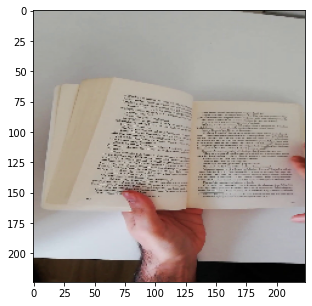

In [10]:
plt.figure(figsize = (5,5))
plt.imshow(train_data[0][0])

### **Build a Convolutional Neural Network:**

Building a Convolutional Neuran Network allows us to find patterns in our images.

In order to do that we need to follow the steps bellow:

- Load our images
- Preprocess our images
- Build a CNN to fin patterns in our images
- Compile the CNN model
- Fit the CNN to our training data

In [11]:
# Set the random seed:
tf.random.set_seed(123)

### **Normalization/Scaling:** (get all of the pixel values between 0 & 1)

In [12]:
train_datagen  =ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

In [13]:
#Setup path to data directories
train_dir="images/training"
test_dir = "images/testing"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size=32,
                                               target_size = (224,224),
                                               class_mode="binary",
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode="binary",
                                               seed=42)

Found 2392 images belonging to 2 classes.
Found 597 images belonging to 2 classes.


### **Create the CNN model**:

In [14]:
model =Sequential([
                   Conv2D(filters=10,
                          kernel_size = (3,3),
                          strides =(1,1),
                          padding ="valid",
                          activation="relu",
                          input_shape = (224,224,3)),  # input layer
                     Conv2D(10,3,activation="relu"),
                     Conv2D(10,3,activation="relu"),
                       Flatten(),
                     Dense(1, activation="sigmoid")    # output layer 
])

### **Compile CNN model:**

In [15]:
model.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

### **Fit the model:**

In [16]:
CNN_model= model.fit(train_data,
                       epochs=5,
                       steps_per_epoch=len(train_data),
                       validation_data=valid_data,
                       validation_steps = len(valid_data))

Epoch 1/5
75/75 [==============================] - 279s 4s/step - loss: 1.5710 - accuracy: 0.6505 - val_loss: 0.4452 - val_accuracy: 0.7672
Epoch 2/5
75/75 [==============================] - 279s 4s/step - loss: 0.2125 - accuracy: 0.9314 - val_loss: 0.1740 - val_accuracy: 0.9229
Epoch 3/5
75/75 [==============================] - 276s 4s/step - loss: 0.0697 - accuracy: 0.9795 - val_loss: 0.0703 - val_accuracy: 0.9715
Epoch 4/5
75/75 [==============================] - 274s 4s/step - loss: 0.0203 - accuracy: 0.9958 - val_loss: 0.0212 - val_accuracy: 0.9950
Epoch 5/5
75/75 [==============================] - 274s 4s/step - loss: 0.0035 - accuracy: 0.9996 - val_loss: 0.0373 - val_accuracy: 0.9832


In [17]:
print(f"The accuracy of the model on the training data: {np.max(CNN_model.history['accuracy']):.4f}")
print(f"The accuracy of the model on the testing data: {np.max(CNN_model.history['val_accuracy']):.4f}")

The accuracy of the model on the training data: 0.9996
The accuracy of the model on the testing data: 0.9950


### **Model summary:**

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 10)      280       
                                                                 
 conv2d_1 (Conv2D)           (None, 220, 220, 10)      910       
                                                                 
 conv2d_2 (Conv2D)           (None, 218, 218, 10)      910       
                                                                 
 flatten (Flatten)           (None, 475240)            0         
                                                                 
 dense (Dense)               (None, 1)                 475241    
                                                                 
Total params: 477,341
Trainable params: 477,341
Non-trainable params: 0
_________________________________________________________________


### **Model evaluation:**

In [19]:
model.evaluate(valid_data)

19/19 [==============================] - 32s 2s/step - loss: 0.0373 - accuracy: 0.9832


[0.03732559084892273, 0.9832496047019958]

### **Visualize Training Results:**
Create plots of the loss and accuracy on the training and validation sets:


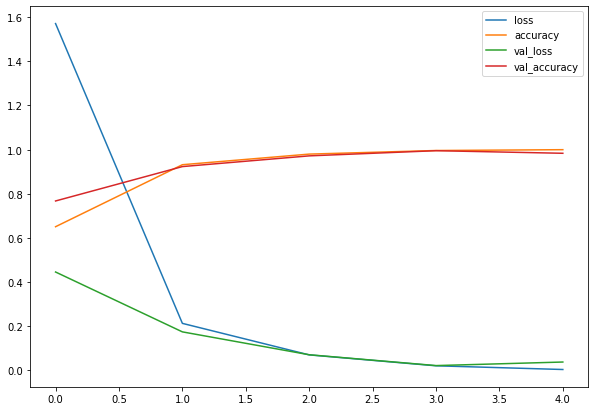

In [20]:
pd.DataFrame(CNN_model.history).plot(figsize=(10,7));

In [21]:
def plot_accuracy_curves(CNN_model):
  """
  Returns separte loss curves for training and validation metrics.
  """
  loss= CNN_model.history["loss"]
  val_loss =CNN_model.history["val_loss"]

  accuracy = CNN_model.history["accuracy"]
  val_accuracy = CNN_model.history["val_accuracy"]


  epochs =range(len(CNN_model.history["loss"]))

  # plot loss
  plt.plot(epochs, loss, label="training_loss")
  plt.plot(epochs, val_loss, label="val_loss")
  plt.title('loss')
  plt.xlabel("epochs")
  plt.legend()

  # plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label="training_accuracy")
  plt.plot(epochs, val_accuracy, label="val_accuracy")
  plt.title("accuracy")
  plt.xlabel("epochs")
  plt.legend()

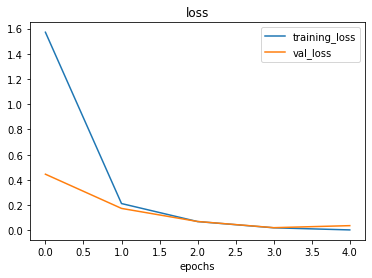

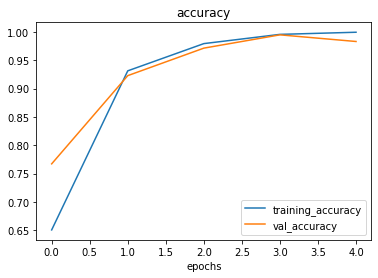

In [22]:
plot_accuracy_curves(CNN_model);

### **Conclusion:**

The goal of the project was to work on a page-flip technology and to predict from low-resolution images whether a page is bein'g flipped or not. The data was provided by the company consisting of the images and associated labels of the flip and nonflip. I started by loading the data into two separate datasets for training and testing. Then, I resized and rescaled the images to be in a lower dimension which leads to the simplest modeling and computation.

Our model accuracy on the training data is: 99.96% and 99.50% on the testing data.